In [1]:
from pybm.convert.probmot import load_library, load_model
import os 


library = load_library("./probmot/AquaticEcosystem.pbl")
incomplete_model = load_model("./probmot/BledIncompleteStructure.pbm", library)

In [2]:
import pandas as pd
from pybm.model import TimeSeries

names = ["00.data", "01.data", "02.data", "95-01.data", "95.data", "96.data", "97.data", "98.data", "99.data"]
dfs = []

# for name in names:
#     df = pd.read_csv("./data/" + name, sep=" ")
#     dfs.append(df)
# df  = pd.concat(dfs, ignore_index=True)

df = pd.read_csv("./data/00.data", sep=" ")

VAR_TO_COLUMN = {
    # eksogene (podatki, ki poganjajo model)
    "ortp.conc": "ortp",              # ortofosfat
    "no.conc": "no",                  # nitrat/dušik
    "silica.conc": "silica",          # silicij
    "daph.conc": "daph_lit",          # dafnija - v teh primerih EKSOGENA (opazovana), ne modelirana
    "env.temperature": "temp",
    "env.light": "light_m",           # NE "light" - uporabljajo "light_m" različico

    # endogena (tarča fita/simulacije)
    "phyto.conc": "phyto",
}

t_full = df["t"].values
for varname, column in VAR_TO_COLUMN.items():
    time_series = TimeSeries(t_full, df[column].values)
    incomplete_model.vars[varname].data = time_series

In [3]:
# get best model 
from pybm.estimate.estimate import estimate_model
#results = estimate_model(incomplete_model, t_eval=t, recepie="gp", verbose=1, max_iter_loss=10, max_gp_iter=50, 
#                         ftol=1e-3, xtol=1e-3, gtol=1e-3, max_nfev=50, collocation_times=collocation_times)

## Hitrejša ocena: `decompose=True`

Zgornja celica reši strukturno dvoumnost s surovo silo: `estimate_model` sprehodi cel Kartezični
produkt vseh odprtih `Choose`/`ChooseProcess` izbir naenkrat. Pri gradient matchingu (`recepie="gp"`)
to ni potrebno - vsaka spremenljivka svojo "trenutno vrednost" ob vsaki časovni točki vedno bere iz
svojega GP-ja, nikoli iz simulacije katere druge spremenljivke, zato je fit konstant za eno
neodvisno strukturno skupino dokazljivo neodvisen od fita za drugo (glej docstring v
`pybm.model_graph`). `estimate_model(..., decompose=True)` to izkoristi: model razdeli na neodvisne
bloke (`pybm.model_graph.build_blocks`) in vsak blok reši posebej, namesto da bi vse kombinacije
množil skupaj - kombinatorična eksplozija (`∏ velikost_izbire`) postane vsota (`Σ velikost_izbire`).

Rezultat je matematično enak (preverjeno s testi, ki `decompose=True` primerjajo z
`decompose=False` na sintetičnih modelih z znano resnico), le hitreje izračunan. Na voljo samo za
`recepie="gp"` (`"gp+ms"`/`"ms"` dejansko simulirata ODE naprej, kar bloke dejansko poveže).

In [4]:
# Ogled blokov, na katere se bo model razdelil - koliko neodvisnih strukturnih iskanj namesto
# enega samega velikega (samo za vpogled, decompose=True to naredi sam)
from pybm.model_graph import build_blocks

for block in build_blocks(incomplete_model):
    state_names = [v.name for v in block.state_vars]
    external_names = [v.name for v in block.external_state_vars]
    print(f"blok {state_names}: {len(block.var_slot_indices)} Choose + "
          f"{len(block.process_slot_indices)} ChooseProcess izbir, bere: {external_names}")

blok ['conc', 'conc', 'conc', 'conc', 'conc']: 0 Choose + 7 ChooseProcess izbir, bere: []


In [5]:
t = t_full
collocation_times = t[::10]  # every 10th time point for collocation

# Ista klic kot zgoraj (isti parametri), le z decompose=True - vrne isti tip rezultata
# (FullEstimationResults: best_consts, best_const_by_name, best_loss, all_results)
load = None
if load is None:
    results_decomp = estimate_model(
        incomplete_model, t_eval=t, recepie="gp", decompose=True, verbose=1, max_iter_loss=10,
        max_gp_iter=300, ftol=1e-3, xtol=1e-3, gtol=1e-3, max_nfev=1000, collocation_times=collocation_times,
    )

    print("\nnajboljše konstante (decompose=True):")
    for name, value in results_decomp.best_const_by_name.items():
        print(f"  {name}: {value:.6g}")
    print(f"best_loss: {results_decomp.best_loss:.6g}")
    # save 
    import pickle
    from datetime import datetime

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    with open(f"results_decomp_{timestamp}.pkl", "wb") as f:
        pickle.dump(results_decomp, f)
else:
    import pickle
    with open(load, "rb") as f:
        results_decomp = pickle.load(f)
    print(f"Loaded results from {load}")
    print("\nnajboljše konstante (decompose=True):")
    for name, value in results_decomp.best_const_by_name.items():
        print(f"  {name}: {value:.6g}")
    print(f"best_loss: {results_decomp.best_loss:.6g}")

[decompose] block (conc, conc, conc, conc, conc): 100%|██████████| 1344/1344 [05:18<00:00,  4.22it/s]


[decompose] block (conc, conc, conc, conc, conc): 1344 candidate(s), best cost=0.0217
[decompose] final model: 0 var slots, 7 process slots, 21 constants


Assembling final constants: 100%|██████████| 21/21 [00:00<00:00, 341396.84it/s]


Integrating final model..
Integrating model with engine torch..


Single-shooting loss optimization: 100%|██████████| 10/10 [02:05<00:00, 12.53s/it]



najboljše konstante (decompose=True):
  ortp.halfSaturation: 7.5
  ortp.alpha: 14353.8
  no.halfSaturation: 1.72831
  no.alpha: 1507.77
  silica.halfSaturation: 14.0378
  silica.alpha: 72.5313
  phyto.maxGrowthRate: 2.78502
  daph.maxFiltrationRate: 0.01
  daph.assimilationCoeff: 6.30328
  env.volume: -2.0193
  env.depth: 10
  env.area: 5.6701e-13
  nutrientPPInteraction.growth.LinearTempGrowthLim_14.refTemp: 10.8773
  nutrientPPInteraction.growth.LinearTempGrowthLim_14.minTemp: 3
  nutrientPPInteraction.growth.LinearTempGrowthLim_14.optTemp: 20
  LightInfluence_4.optLight: 102.65
  RespirationPP_29.respRate: 0.00676179
  TempGrowthInfluence_32.refTemp: 22
  TempGrowthInfluence_32.minTemp: 3
  TempGrowthInfluence_32.optTemp: 20
  PhytoLim_40.halfSaturation: 20
best_loss: 0.285147


In [6]:
# ProBMoT-ove referenčne vrednosti za znano pravilno strukturo - prebrane direktno iz BledComplete.pbm
# (ProBMoT-ova že rešena "prava" rešitev za ta problem). Per-parametrska imena se NE ujemajo nujno
# z najino iskano strukturo (glej opombo v zadnji celici), zato je primerjava spodaj na nivoju
# simulirane trajektorije, ne posameznih konstant.
TRUE_VALUES = {
    "ortp.halfSaturation": 0.5604633993464766,
    "no.halfSaturation": 0.005439851527049321,
    "silica.halfSaturation": 4.239434744795273,
    "phyto.maxGrowthRate": 3.0,
    "daph.maxFiltrationRate": 0.03737605860906343,
    "lightInfluence19.optLight": 100.49292986819768,
    "tempGrowthLim906.refTemp": 10.0,
    "respirationPP381.respRate": 1.0e-4,
    "tempRespInfluence396.refTemp": 15.60799148612582,
}
TRUE_INITIAL_PHYTO_CONC = 2.3002014225415075

MSE (najin rezultat, decompose=True): 0.2851
MSE (ProBMoT, BledComplete):          2.664


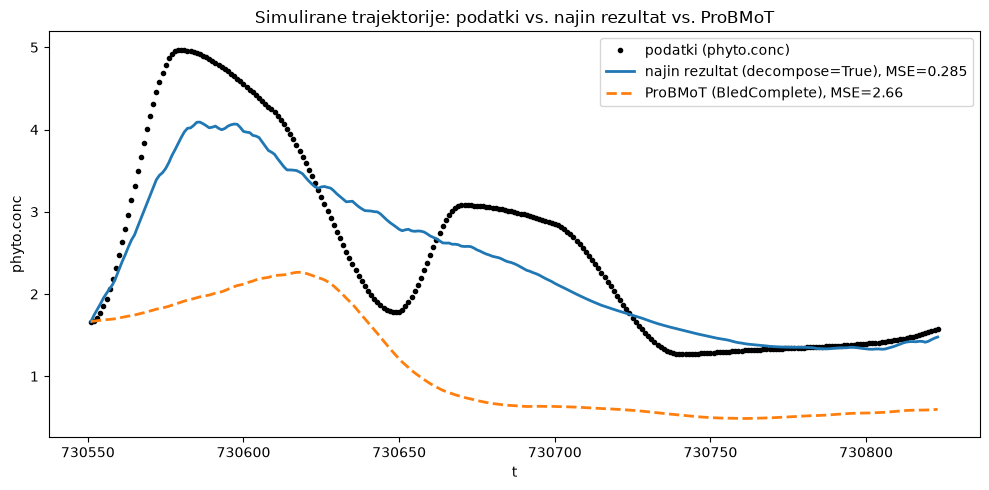

In [ ]:
# Primerjava naših rezultatov (decompose=True) s ProBMoT-ovim že rešenim modelom (BledComplete.pbm)
#
# BledComplete.pbm nima strukturne dvoumnosti - konstante so že rešene, prebrane direktno iz
# datoteke (glej TRUE_VALUES zgoraj) - to je ProBMoT-ov "rezultat" za ta problem. Obe simulaciji
# poganjamo z istimi eksogenimi podatki (VAR_TO_COLUMN) in istim, dejansko izmerjenim začetnim
# pogojem (simulate(..., initial=None) prebere phyto.conc iz podatkov pri t[0]), da je primerjava
# poštena - razlike v spodnjih trajektorijah izhajajo samo iz razlik v strukturi/konstantah, ne iz
# drugačnih vhodov. phyto.conc je edina diferencialna (state) spremenljivka v tem modelu - vse
# ostalo (ortp/no/silica/daph/env.*) je eksogena vhodna podatkovna vrsta - zato ima simulate() samo
# EN stolpec (sim.vars == ["conc"]).
#
# Imena konstant se med najino iskano strukturo in BledComplete NE ujemajo nujno (najina struktura
# je bila izbrana arbitrarno izmed 1344 kandidatov, glej opombo ob TRUE_VALUES) - zato primerjamo
# na nivoju SIMULIRANE TRAJEKTORIJE (structure-agnostic), ne posameznih konstant po imenu.
import numpy as np
import matplotlib.pyplot as plt
from pybm.estimate.analysis_torch import simulate

probmot_model = load_model("./probmot/BledComplete.pbm", library).induce()[0]
for varname, column in VAR_TO_COLUMN.items():
    probmot_model.vars[varname].data = TimeSeries(t, df[column].values[: len(t)])
probmot_model.switch_engine("torch")

probmot_consts = np.zeros(len(probmot_model.consts))
for name, const in probmot_model.consts.items():
    probmot_consts[const.index_in_ctx] = const.initial_value

ours = simulate(results_decomp.best_model, t, results_decomp.best_consts)
probmot = simulate(probmot_model, t, probmot_consts)

ours_phyto = ours.y[0]
probmot_phyto = probmot.y[0]
data_phyto = df["phyto"].values[: len(t)]

ours_mse = float(np.mean((ours_phyto - data_phyto) ** 2))
probmot_mse = float(np.mean((probmot_phyto - data_phyto) ** 2))
print(f"MSE (nova metoda, decompose=True): {ours_mse:.4g}")
print(f"MSE (ProBMoT, BledComplete):          {probmot_mse:.4g}")


plot_lenght=50
plt.figure(figsize=(10, 5))
plt.plot(t, data_phyto, "o", color="black", markersize=3, label="podatki (phyto.conc)")
plt.plot(t, ours_phyto, "-", linewidth=2, label=f"nova metoda (decompose=True), MSE={ours_mse:.3g}")
plt.plot(t, probmot_phyto, "--", linewidth=2, label=f"ProBMoT (BledComplete), MSE={probmot_mse:.3g}")
plt.xlabel("t")
plt.ylabel("phyto.conc")
plt.title("Simulirane trajektorije: podatki vs. nova metoda vs. ProBMoT")
plt.legend()
plt.tight_layout()
plt.show()

# OPOMBA (pomembna): nova metoda ima gradientnega ujemanja lasten cost zelo majhen (best_cost
# ~1e-5 - glej izpis zgornje celice), a njegova FORWARD-SIMULIRANA trajektorija zna hitro odstopiti
# od podatkov (glej graf) - medtem ko ProBMoT-ova (BledComplete) trajektorija sledi podatkom precej
# bolje. To ni protislovje: gradientno ujemanje nikoli ne simulira ODE naprej (glej razdelek 2 v
# učbeniku o razklopu) - njegov cost meri, kako dobro konstante ujamejo GP-jev ODVOD na peščici
# kolokacijskih točk, ne kako dobro se napaka NE kopiči čez celoten horizont pri resnični integraciji.
# Zato v `pybm.estimate.gradient_matching.estimate_gradient_matching`-ovem docstringu tudi piše, da
# je "only a fast initializer for a proper estimator" - namenjen kot dober ZAČETEK za nadaljnje
# multishooting-based prečiščenje (`recepie="gp+ms"`), ki pa v tem repozitoriju še ni
# implementirano (`_gp_plus_ms` trenutno vrže `NotImplementedError`). ProBMoT po drugi strani vsak
# kandidat ocenjuje z diferencialno evolucijo NEPOSREDNO na resnični simulirani trajektoriji - zato
# je njegov rezultat tu boljši, po ceni veliko počasnejšega iskanja (glej pogovor o ProBMoT-u zgoraj
# v chatu).

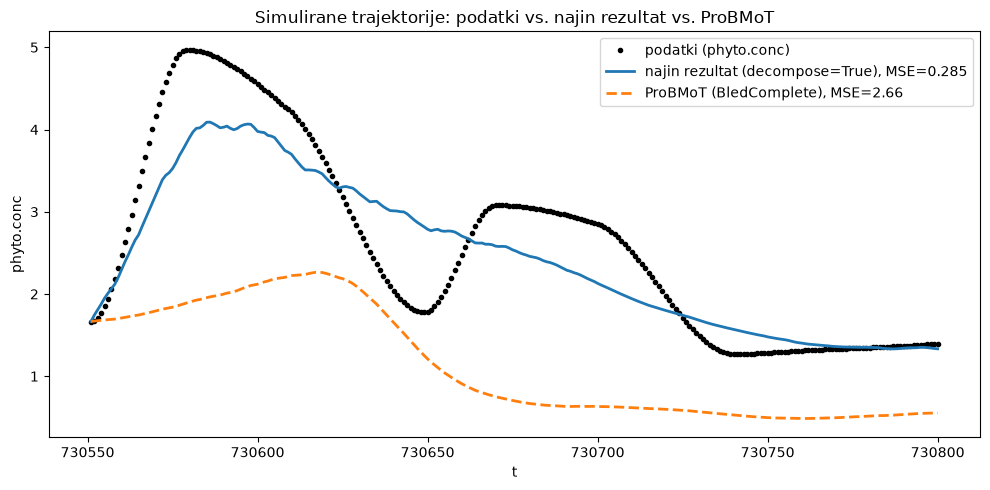

In [9]:
plot_lenght=250
plt.figure(figsize=(10, 5))
plt.plot(t[:plot_lenght], data_phyto[:plot_lenght], "o", color="black", markersize=3, label="podatki (phyto.conc)")
plt.plot(t[:plot_lenght], ours_phyto[:plot_lenght], "-", linewidth=2, label=f"najin rezultat (decompose=True), MSE={ours_mse:.3g}")
plt.plot(t[:plot_lenght], probmot_phyto[:plot_lenght], "--", linewidth=2, label=f"ProBMoT (BledComplete), MSE={probmot_mse:.3g}")
plt.xlabel("t")
plt.ylabel("phyto.conc")
plt.title("Simulirane trajektorije: podatki vs. najin rezultat vs. ProBMoT")
plt.legend()
plt.tight_layout()
plt.show()